In [1]:
import kairo
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(Path("..") / ".env")

True

In [7]:
log = kairo.read_log("../data/waiting-time.xes",
    case_id = "case:concept:name",
    activity = "concept:name",
    timestamp = "time:timestamp",
    event_id = "event:id",
    start_timestamp = "start_timestamp",
    resource = "org:resource",
    event_duration = "event:duration_min")
log.head()

,org:resource,case:region,start_timestamp,concept:name,event_id,time:timestamp,case:amount,case:concept:name,event_duration
0,res_05,region_3,2020-01-01 00:00:00+00:00,a,evt_00000001,2020-01-01 00:26:42.410373+00:00,647.69,case_000001,26.706840
1,res_05,region_3,2020-01-01 00:01:17.353317+00:00,a,evt_00000002,2020-01-01 00:55:21.249723+00:00,997.83,case_000002,54.064940
2,res_04,region_3,2020-01-01 01:05:49.771917+00:00,b,evt_00000003,2020-01-01 01:42:06.554846+00:00,997.83,case_000002,36.279715
3,res_04,region_3,2020-01-01 01:53:18.229475+00:00,c,evt_00000004,2020-01-01 02:37:36.979041+00:00,997.83,case_000002,44.312493
4,res_06,region_3,2020-01-01 02:57:08.654875+00:00,f,evt_00000005,2020-01-01 03:16:44.467898+00:00,997.83,case_000002,19.596884


In [8]:
stats = kairo.compute_log_stats(log)
stats

{'cases': 300299,
 'events': 1946540,
 'activities': 7,
 'resources': 7,
 'start': Timestamp('2020-01-01 00:23:35.993832+0000', tz='UTC'),
 'end': Timestamp('2021-01-03 02:40:08.402917+0000', tz='UTC'),
 'span_minutes': 530056.5401514167,
 'tpt_days_min': 0.0,
 'tpt_days_mean': 0.25873165834269923,
 'tpt_days_median': 0.0,
 'tpt_days_max': 4.939182079756945,
 'length_min': 1,
 'length_mean': 6.482006267087137,
 'length_median': 1.0,
 'length_max': 94,
 'activity_counts': concept:name
 a    599657
 b    299358
 f    299358
 g    299358
 c    149907
 d    149451
 e    149451
 Name: count, dtype: int64,
 'resource_counts': org:resource
 res_05    776022
 res_04    415219
 res_06    414769
 res_07    174528
 res_01     55510
 res_02     55394
 res_03     55098
 Name: count, dtype: int64}

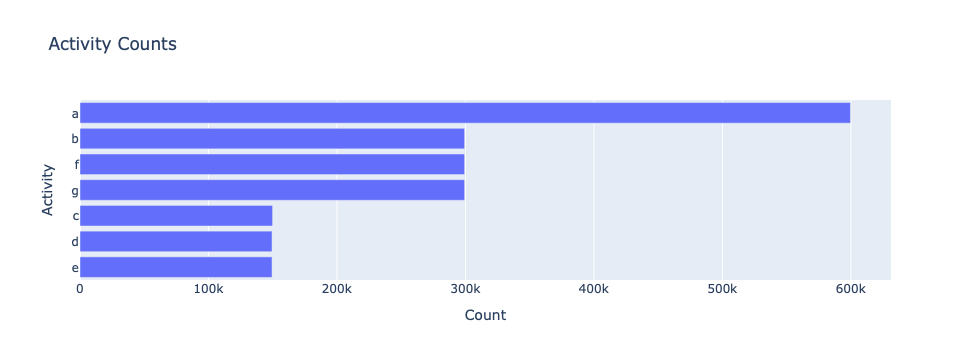

In [9]:
activity_plot = kairo.plot_activity_counts(stats)
activity_plot.show()

In [17]:
# one row per calendar window, the case attributes with their kind,
# e.g. {"case:amount": "numerical", "case:region": "categorical"}
features = kairo.compute_features_inter(log, window="12h",
    case_attributes={"case:region": "categorical", "case:amount": "numerical"},
    stall_threshold="60D")
features

,time:timestamp,active_cases,new_arrivals,completions,events_per_case,mean_delta_t,std_delta_t,stalled_cases,attr_means:case:amount,attr_stds:case:amount,attr_shares:case:region=region_1,attr_shares:case:region=region_2,attr_shares:case:region=region_3,attr_shares:case:region=region_4
0,2020-01-01 00:00:00+00:00,380.0,380.0,247.0,3.978947,45.714204,15.446056,0.0,1014.096012,189.404526,0.028439,0.052249,0.840608,0.078704
1,2020-01-01 12:00:00+00:00,557.0,424.0,416.0,4.822262,46.169186,15.673509,0.0,1000.512126,195.046708,0.026061,0.047282,0.871556,0.055101
2,2020-01-02 00:00:00+00:00,555.0,414.0,408.0,4.850450,46.815493,15.585387,0.0,1007.633109,197.636248,0.048291,0.077637,0.820579,0.053492
3,2020-01-02 12:00:00+00:00,556.0,409.0,391.0,4.985612,46.526424,15.334017,0.0,1015.747219,199.577623,0.063492,0.051587,0.830447,0.054473
4,2020-01-03 00:00:00+00:00,578.0,413.0,423.0,4.880623,47.045621,15.250061,0.0,1027.035569,197.361744,0.071251,0.038993,0.821694,0.068061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732,2021-01-01 00:00:00+00:00,29.0,0.0,13.0,7.206897,75.743518,13.939137,0.0,1033.467081,189.190444,0.000000,0.071770,0.880383,0.047847
733,2021-01-01 12:00:00+00:00,16.0,0.0,10.0,6.562500,77.280074,15.974091,0.0,1042.997619,182.397872,0.000000,0.000000,0.971429,0.028571
734,2021-01-02 00:00:00+00:00,6.0,0.0,3.0,6.500000,76.326157,18.564973,0.0,1068.490000,192.682004,0.000000,0.000000,1.000000,0.000000
735,2021-01-02 12:00:00+00:00,3.0,0.0,2.0,7.000000,76.732739,14.488273,0.0,1062.351905,238.082213,0.000000,0.000000,1.000000,0.000000


In [18]:
std_features = kairo.standardize(features, method="minmax")
std_features

,time:timestamp,active_cases,new_arrivals,completions,events_per_case,mean_delta_t,std_delta_t,stalled_cases,attr_means:case:amount,attr_stds:case:amount,attr_shares:case:region=region_1,attr_shares:case:region=region_2,attr_shares:case:region=region_3,attr_shares:case:region=region_4
0,2020-01-01 00:00:00+00:00,0.526389,0.788382,0.507216,0.380063,0.000000,0.325761,0.0,0.754827,0.795543,0.289930,0.607761,0.272905,0.818454
1,2020-01-01 12:00:00+00:00,0.772222,0.879668,0.855670,0.542024,0.009873,0.374932,0.0,0.693600,0.819241,0.265686,0.549990,0.414079,0.573000
2,2020-01-02 00:00:00+00:00,0.769444,0.858921,0.839175,0.547438,0.023899,0.355882,0.0,0.725697,0.830118,0.492317,0.903085,0.181539,0.556271
3,2020-01-02 12:00:00+00:00,0.770833,0.848548,0.804124,0.573396,0.017626,0.301541,0.0,0.762270,0.838272,0.647286,0.600067,0.226553,0.566478
4,2020-01-03 00:00:00+00:00,0.801389,0.856846,0.870103,0.553232,0.028893,0.283392,0.0,0.813150,0.828965,0.726390,0.453573,0.186625,0.707778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732,2021-01-01 00:00:00+00:00,0.038889,0.000000,0.024742,1.000000,0.651657,0.000000,0.0,0.842140,0.794643,0.000000,0.834838,0.454343,0.497568
733,2021-01-01 12:00:00+00:00,0.020833,0.000000,0.018557,0.876242,0.685001,0.439911,0.0,0.885097,0.766113,0.000000,0.000000,0.869666,0.297119
734,2021-01-02 00:00:00+00:00,0.006944,0.000000,0.004124,0.864238,0.664300,1.000000,0.0,1.000000,0.809309,0.000000,0.000000,1.000000,0.000000
735,2021-01-02 12:00:00+00:00,0.002778,0.000000,0.002062,0.960265,0.673123,0.118711,0.0,0.972333,1.000000,0.000000,0.000000,1.000000,0.000000


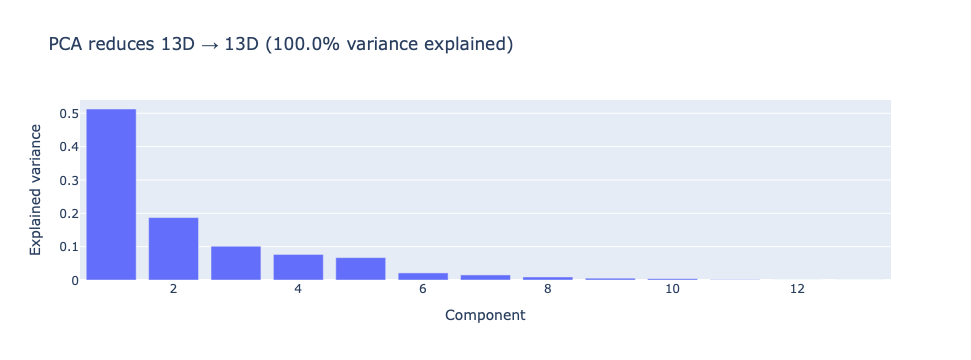

In [22]:
pca = kairo.compute_pca(std_features, num_components=13)
pca_plot = kairo.plot_pca_variances(pca)
pca_plot.show()
#pca

In [23]:
compressed_features = kairo.apply_pca(std_features, pca, cut_component=7)
compressed_features

,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7
0,2020-01-01 00:00:00+00:00,-0.508319,0.139593,0.160462,0.388919,-0.227101,-0.071872,0.074677
1,2020-01-01 12:00:00+00:00,-0.476249,0.096801,0.023974,-0.035255,-0.262815,0.003537,0.076940
2,2020-01-02 00:00:00+00:00,-0.462033,-0.199669,0.319513,0.027980,-0.032921,0.016580,0.069266
3,2020-01-02 12:00:00+00:00,-0.498622,-0.110417,0.024519,0.086567,0.095557,0.070095,0.006683
4,2020-01-03 00:00:00+00:00,-0.489749,-0.189851,-0.164370,0.187891,0.086832,0.108939,-0.007483
...,...,...,...,...,...,...,...,...
732,2021-01-01 00:00:00+00:00,-0.126298,1.100181,0.898370,0.796607,0.022088,0.178254,-0.408911
733,2021-01-01 12:00:00+00:00,-0.046057,1.682203,0.143411,0.618386,0.078852,0.206726,0.001302
734,2021-01-02 00:00:00+00:00,0.012517,1.868688,0.179768,0.387117,0.211621,0.326272,0.549988
735,2021-01-02 12:00:00+00:00,-0.118993,1.839985,0.208116,0.378612,0.192934,0.409220,-0.337973


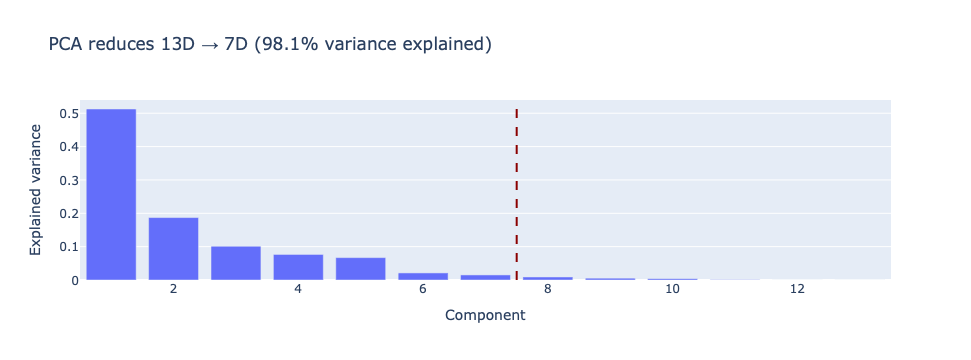

In [24]:
pca_plot_cut = kairo.plot_pca_variances(pca, cut_component=7)
pca_plot_cut.show()

In [38]:
som = kairo.compute_som(compressed_features, size=(2,2))
clusters = kairo.get_som_winners(compressed_features, som)
clusters

,i,j
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
732,0,1
733,0,1
734,0,1
735,0,1


In [39]:
features_and_clusters = pd.concat([compressed_features, clusters], axis=1)
features_and_clusters

,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,i,j
0,2020-01-01 00:00:00+00:00,-0.508319,0.139593,0.160462,0.388919,-0.227101,-0.071872,0.074677,1,1
1,2020-01-01 12:00:00+00:00,-0.476249,0.096801,0.023974,-0.035255,-0.262815,0.003537,0.076940,1,1
2,2020-01-02 00:00:00+00:00,-0.462033,-0.199669,0.319513,0.027980,-0.032921,0.016580,0.069266,1,1
3,2020-01-02 12:00:00+00:00,-0.498622,-0.110417,0.024519,0.086567,0.095557,0.070095,0.006683,1,1
4,2020-01-03 00:00:00+00:00,-0.489749,-0.189851,-0.164370,0.187891,0.086832,0.108939,-0.007483,1,1
...,...,...,...,...,...,...,...,...,...,...
732,2021-01-01 00:00:00+00:00,-0.126298,1.100181,0.898370,0.796607,0.022088,0.178254,-0.408911,0,1
733,2021-01-01 12:00:00+00:00,-0.046057,1.682203,0.143411,0.618386,0.078852,0.206726,0.001302,0,1
734,2021-01-02 00:00:00+00:00,0.012517,1.868688,0.179768,0.387117,0.211621,0.326272,0.549988,0,1
735,2021-01-02 12:00:00+00:00,-0.118993,1.839985,0.208116,0.378612,0.192934,0.409220,-0.337973,0,1


In [40]:
state_distances = kairo.get_som_state_distances(som)
state_distances

,"(0, 0)","(0, 1)","(1, 0)","(1, 1)"
"(0, 0)",0.000000,0.481068,0.249834,0.693567
"(0, 1)",0.481068,0.000000,0.408123,0.542027
"(1, 0)",0.249834,0.408123,0.000000,0.675777
"(1, 1)",0.693567,0.542027,0.675777,0.000000


In [41]:
state_freqs = kairo.get_som_state_frequencies(features_and_clusters)
state_freqs

state
(0, 0)    211
(0, 1)      8
(1, 0)    299
(1, 1)    219
Name: windows, dtype: int64

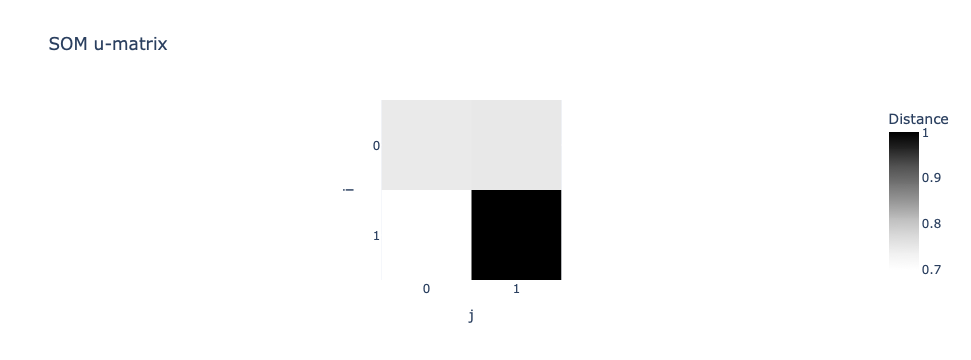

In [42]:
u_matrix_plot = kairo.plot_som_u_matrix(som)
u_matrix_plot.show()

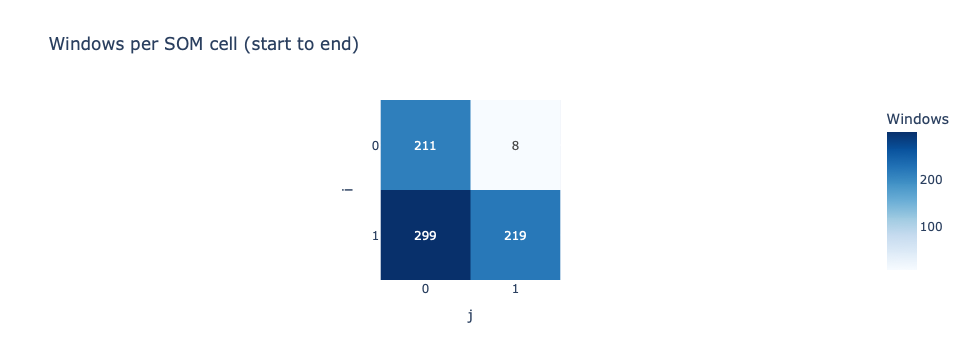

In [43]:
heatmap_plot = kairo.plot_som_heatmap(features_and_clusters, size=(2,2),
                                 #start_date="2017-06-01",
                                 #end_date="2018-11-26"
                                 )
heatmap_plot.show()

In [44]:
color_mapping = kairo.compute_som_color_mapping((2,2))
#color_mapping

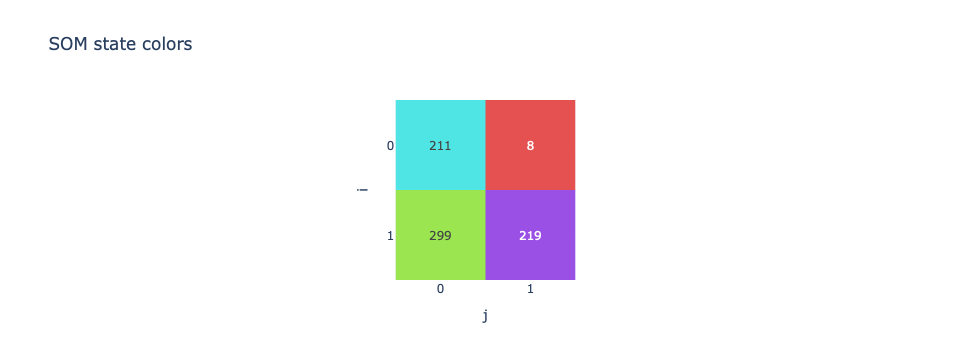

In [45]:
state_colors_plot = kairo.plot_som_colors(features_and_clusters, color_mapping)
state_colors_plot.show()

In [46]:
log_trajectory = kairo.get_som_log_trajectory(features_and_clusters,
                                 #start_date="2017-06-01",
                                 #end_date="2018-11-26"
                                 )
log_trajectory

,state,start,end,duration,windows
0,"(1, 1)",2020-01-01 00:00:00+00:00,2020-04-19 12:00:00+00:00,109 days 12:00:00,219
1,"(1, 0)",2020-04-19 12:00:00+00:00,2020-04-20 00:00:00+00:00,0 days 12:00:00,1
2,"(0, 0)",2020-04-20 00:00:00+00:00,2020-04-21 00:00:00+00:00,1 days 00:00:00,2
3,"(1, 0)",2020-04-21 00:00:00+00:00,2020-04-23 12:00:00+00:00,2 days 12:00:00,5
4,"(0, 0)",2020-04-23 12:00:00+00:00,2020-04-24 12:00:00+00:00,1 days 00:00:00,2
...,...,...,...,...,...
168,"(0, 0)",2020-12-24 12:00:00+00:00,2020-12-26 12:00:00+00:00,2 days 00:00:00,4
169,"(1, 0)",2020-12-26 12:00:00+00:00,2020-12-27 12:00:00+00:00,1 days 00:00:00,2
170,"(0, 0)",2020-12-27 12:00:00+00:00,2020-12-29 00:00:00+00:00,1 days 12:00:00,3
171,"(1, 0)",2020-12-29 00:00:00+00:00,2020-12-31 00:00:00+00:00,2 days 00:00:00,4


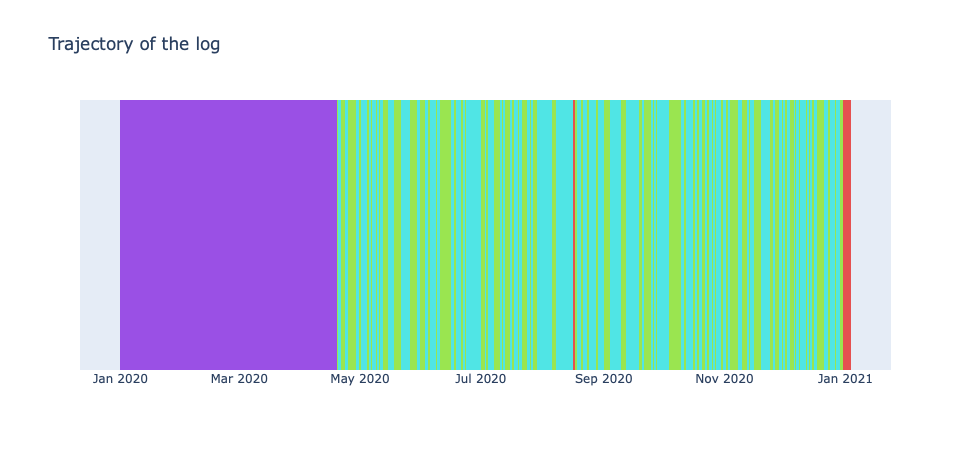

In [47]:
log_trajectory_plot = kairo.plot_som_log_trajectory(log_trajectory, color_mapping)
log_trajectory_plot

In [52]:
# the states of the daily windows counted per 30 days
freq_distributions = kairo.compute_state_distributions(features_and_clusters, window="3D")
freq_distributions

state,"(0, 0)","(0, 1)","(1, 0)","(1, 1)"
window,,,,
2019-12-31 00:00:00+00:00,0.000000,0.0,0.000000,1.0
2020-01-03 00:00:00+00:00,0.000000,0.0,0.000000,1.0
2020-01-06 00:00:00+00:00,0.000000,0.0,0.000000,1.0
2020-01-09 00:00:00+00:00,0.000000,0.0,0.000000,1.0
2020-01-12 00:00:00+00:00,0.000000,0.0,0.000000,1.0
...,...,...,...,...
2020-12-22 00:00:00+00:00,0.500000,0.0,0.500000,0.0
2020-12-25 00:00:00+00:00,0.666667,0.0,0.333333,0.0
2020-12-28 00:00:00+00:00,0.333333,0.0,0.666667,0.0


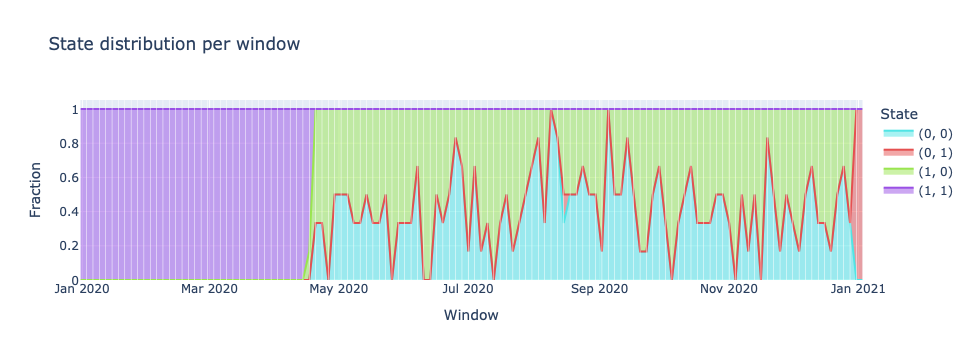

In [53]:
distributions_plot = kairo.plot_state_distributions(freq_distributions, color_mapping)
distributions_plot.show()

In [63]:
divergences = kairo.compute_divergences(freq_distributions, reference="recent", lookback=5)
divergences

,window,score
0,2019-12-31 00:00:00+00:00,NaN
1,2020-01-03 00:00:00+00:00,NaN
2,2020-01-06 00:00:00+00:00,NaN
3,2020-01-09 00:00:00+00:00,NaN
4,2020-01-12 00:00:00+00:00,NaN
...,...,...
119,2020-12-22 00:00:00+00:00,0.020411
120,2020-12-25 00:00:00+00:00,0.144622
121,2020-12-28 00:00:00+00:00,0.009466
122,2020-12-31 00:00:00+00:00,20.723266


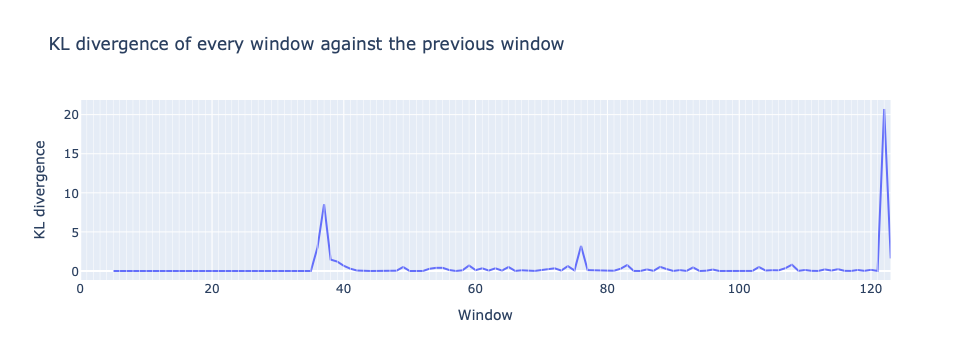

In [64]:
divergences_plot = kairo.plot_divergences(divergences)
divergences_plot.show()

In [65]:
window_distances = kairo.compute_window_distances(compressed_features, distance="euclidean", reference="previous")
window_distances

,window,score
0,2020-01-01 00:00:00+00:00,NaN
1,2020-01-01 12:00:00+00:00,0.456486
2,2020-01-02 00:00:00+00:00,0.482202
3,2020-01-02 12:00:00+00:00,0.350779
4,2020-01-03 00:00:00+00:00,0.232636
...,...,...
732,2021-01-01 00:00:00+00:00,0.607603
733,2021-01-01 12:00:00+00:00,1.057933
734,2021-01-02 00:00:00+00:00,0.652679
735,2021-01-02 12:00:00+00:00,0.902607


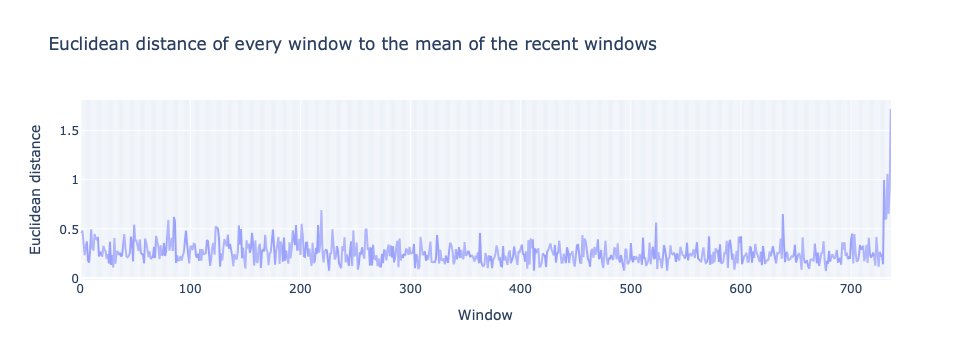

In [68]:
window_distances_plot = kairo.plot_window_distances(window_distances, distance="euclidean", reference="recent")
window_distances_plot.show()

In [69]:
abs_log_stats = kairo.abstract_log_stats(stats)
abs_log_stats

'Event log: 1,946,540 events of 300,299 cases, 7 activities and 7 resources, from 2020-01-01 00:23:35.993832+00:00 to 2021-01-03 02:40:08.402917+00:00.\nThroughput time per case in days: min 0.00, mean 0.26, median 0.00, max 4.94.\nEvents per case: min 1, mean 6.5, median 1.0, max 94.\nEvents per activity: a (599,657), b (299,358), f (299,358), g (299,358), c (149,907), d (149,451), e (149,451)\nMost active resources: res_05 (776,022), res_04 (415,219), res_06 (414,769), res_07 (174,528), res_01 (55,510), res_02 (55,394), res_03 (55,098)'

In [70]:
abs_features = kairo.abstract_features(features)
abs_features

"Inter-case feature matrix: 737 rows, one per calendar window of 0 days 12:00:00, with 13 feature columns.\nThe windows start from 2020-01-01 00:00:00+00:00 to 2021-01-03 00:00:00+00:00.\nFeature groups:\n- active_cases (cases with at least one event in the window): 1 columns, mean value 617.900, non-zero in 100.0% of the cells, highest column means active_cases = 617.900\n- new_arrivals (cases whose first event falls into the window): 1 columns, mean value 407.461, non-zero in 99.2% of the cells, highest column means new_arrivals = 407.461\n- completions (cases whose last event falls into the window): 1 columns, mean value 407.461, non-zero in 100.0% of the cells, highest column means completions = 407.461\n- events_per_case (events in the window divided by the active cases): 1 columns, mean value 4.310, non-zero in 100.0% of the cells, highest column means events_per_case = 4.310\n- mean_delta_t (mean minutes between an event and the previous event of its case): 1 columns, mean value

In [71]:
abs_pca = kairo.abstract_pca(pca, cut_component=5)
abs_pca

'PCA fitted 13 components on 13 feature columns. The cut keeps the first 5, which explain 94.5% of the variance.\nExplained variance per component: pc_1 51.3%, pc_2 18.7%, pc_3 10.1%, pc_4 7.7%, pc_5 6.7%, pc_6 2.1%, pc_7 1.5%, pc_8 0.9%, pc_9 0.5%, pc_10 0.4%, pc_11 0.1%, pc_12 0.0%, pc_13 0.0%\nFeatures with the strongest loadings on every kept component:\n- pc_1: mean_delta_t (+0.95), events_per_case (-0.20), active_cases (+0.19), std_delta_t (+0.13)\n- pc_2: attr_shares:case:region=region_3 (+0.46), attr_shares:case:region=region_2 (-0.37), new_arrivals (-0.37), attr_shares:case:region=region_1 (-0.36)\n- pc_3: attr_shares:case:region=region_2 (+0.87), attr_shares:case:region=region_1 (-0.25), new_arrivals (-0.21), attr_shares:case:region=region_4 (-0.20)\n- pc_4: attr_shares:case:region=region_4 (+0.71), new_arrivals (-0.36), completions (-0.34), active_cases (-0.32)\n- pc_5: attr_shares:case:region=region_1 (+0.82), attr_shares:case:region=region_4 (-0.46), new_arrivals (-0.19), 

In [72]:
abs_states = kairo.abstract_states(state_freqs, state_distances, color_mapping)
abs_states

'4 states occur among the 737 windows. Windows per state:\n- (1, 0): 299 windows (40.6%)\n- (1, 1): 219 windows (29.7%)\n- (0, 0): 211 windows (28.6%)\n- (0, 1): 8 windows (1.1%)\nNearest and farthest other state for every state, by the distance between them:\n- (0, 0): nearest (1, 0) (0.25), farthest (1, 1) (0.69)\n- (0, 1): nearest (1, 0) (0.41), farthest (1, 1) (0.54)\n- (1, 0): nearest (0, 0) (0.25), farthest (1, 1) (0.68)\n- (1, 1): nearest (0, 1) (0.54), farthest (0, 0) (0.69)\nColors of the states in the plots:\n- (0, 0): #50e5e5 (cyan)\n- (0, 1): #e55050 (red)\n- (1, 0): #9ae550 (green)\n- (1, 1): #9a50e5 (purple)'

In [73]:
abs_log_trajectory = kairo.abstract_log_trajectory(log_trajectory)
abs_log_trajectory

'Trajectory of the log through the states from 2020-01-01 00:00:00+00:00 to 2021-01-03 12:00:00+00:00: 737 calendar windows in 173 visits, a visit being a run of consecutive windows in the same state.\nWindows per state, and when the state first and last occurs:\n- (1, 0): 299 windows (40.6%), from 2020-04-19 12:00:00+00:00 to 2020-12-31 00:00:00+00:00\n- (1, 1): 219 windows (29.7%), from 2020-01-01 00:00:00+00:00 to 2020-04-19 12:00:00+00:00\n- (0, 0): 211 windows (28.6%), from 2020-04-20 00:00:00+00:00 to 2020-12-29 00:00:00+00:00\n- (0, 1): 8 windows (1.1%), from 2020-08-16 12:00:00+00:00 to 2021-01-03 12:00:00+00:00\nThe most common moves from one state to the next:\n- (1, 0) -> (0, 0): 84 times\n- (0, 0) -> (1, 0): 84 times\n- (1, 0) -> (0, 1): 2 times\n- (1, 1) -> (1, 0): 1 times\n- (0, 1) -> (1, 0): 1 times\nThe visits in order:\n- (1, 1) from 2020-01-01 00:00:00+00:00 to 2020-04-19 12:00:00+00:00 (219 windows)\n- (1, 0) from 2020-04-19 12:00:00+00:00 to 2020-04-20 00:00:00+00:0

In [74]:
abs_distributions = kairo.abstract_distributions(freq_distributions)
abs_distributions

'State distribution over 124 calendar windows from 2019-12-31 00:00:00+00:00 to 2021-01-03 00:00:00+00:00: the share of every state in each window.\nShare of every state over the windows, mean, lowest and highest:\n- (0, 0): mean 28.4%, lowest 0.0% in the window starting 2019-12-31 00:00:00+00:00, highest 100.0% in the window starting 2020-08-09 00:00:00+00:00\n- (0, 1): mean 1.7%, lowest 0.0% in the window starting 2019-12-31 00:00:00+00:00, highest 100.0% in the window starting 2020-12-31 00:00:00+00:00\n- (1, 0): mean 40.2%, lowest 0.0% in the window starting 2019-12-31 00:00:00+00:00, highest 100.0% in the window starting 2020-04-26 00:00:00+00:00\n- (1, 1): mean 29.7%, lowest 0.0% in the window starting 2020-04-20 00:00:00+00:00, highest 100.0% in the window starting 2019-12-31 00:00:00+00:00\nThe largest changes from one window to the next, with the states that changed most:\n- window starting 2020-12-31 00:00:00+00:00: 100.0% of the mix moved, (0, 1) +100.0%, (1, 0) -66.7%, (0, 

In [75]:
abs_divergences = kairo.abstract_divergences(divergences, divergence="kl", reference="previous")
abs_divergences

'Drift signal: the KL divergence between the state distribution of every calendar window and the previous window, over 124 windows from 2019-12-31 00:00:00+00:00 to 2021-01-03 00:00:00+00:00. The windows are numbered from 0 as in the plot.\nScores: median 0.021, mean 0.441, highest 20.723.\nThe windows with the highest scores:\n- window 122, starting 2020-12-31 00:00:00+00:00: 20.723\n- window 37, starting 2020-04-20 00:00:00+00:00: 8.539\n- window 76, starting 2020-08-15 00:00:00+00:00: 3.207\n- window 36, starting 2020-04-17 00:00:00+00:00: 3.003\n- window 123, starting 2021-01-03 00:00:00+00:00: 1.609'

In [76]:
abs_window_distances = kairo.abstract_window_distances(window_distances, distance="euclidean", reference="previous")
abs_window_distances

'Drift signal: the Euclidean distance between the vector of every calendar window and the previous window, over 737 windows from 2020-01-01 00:00:00+00:00 to 2021-01-03 00:00:00+00:00. The windows are numbered from 0 as in the plot.\nScores: median 0.243, mean 0.261, highest 1.717.\nThe windows with the highest scores:\n- window 736, starting 2021-01-03 00:00:00+00:00: 1.717\n- window 733, starting 2021-01-01 12:00:00+00:00: 1.058\n- window 730, starting 2020-12-31 00:00:00+00:00: 0.997\n- window 735, starting 2021-01-02 12:00:00+00:00: 0.903\n- window 219, starting 2020-04-19 12:00:00+00:00: 0.690'

In [81]:
inp_tokens = kairo.count_input_tokens(provider="custom",
                                system_prompt=kairo.DEFAULT_SYSTEM_PROMPT,
                                prompts=[abs_log_stats, abs_features, abs_pca, abs_states, abs_log_trajectory,
                                         abs_distributions, abs_divergences, abs_window_distances,
                                         "Analyze and very very summarize the given information and tell if there is drift, its type and date. Do not use markdown format, just raw text"],
                                plots=[activity_plot, pca_plot_cut, u_matrix_plot, heatmap_plot, state_colors_plot,
                                       log_trajectory_plot, distributions_plot, divergences_plot, window_distances_plot])

num_tokens, messages = inp_tokens
num_tokens

11746

In [85]:
llm = kairo.LLMConnector(
    provider="custom",
    #api_key=os.environ["ANTHROPIC_API_KEY"],
    model="nvidia/nemotron-3-nano-omni",
    #model="Qwen/Qwen3-VL-32B-Instruct"
    
    #base_url="http://137.226.117.70:8000/v1"
    base_url="http://127.0.0.1:1234/v1"
)

response = llm.call(messages=messages, max_tokens=64000)

In [86]:
out_tokens = kairo.count_output_tokens("custom", response)
out_tokens

812

In [87]:
answer = kairo.get_response_text(response)
print(answer)

Yes. Drift is evident, especially at the end of 2020 – Jan 2021. The KL divergence spikes to >20 in window 122 (starting 2020‑12‑31) and Euclidean distance peaks at 1.7 in window 736 (starting 2021‑01‑03), indicating a sudden change in the state distribution from the long‑term dominance of the green/red states to a mix that includes many red (0,1) windows.
